# EHA Clinics — Tier 3 Demand Forecasting: Facebook Prophet

**Project:** Procurement Demand Forecasting Initiative  
**KPI target:** MAPE ≤ 20% for critical health commodities across pilot facilities by Q3  

This notebook implements **Tier 3** of the forecasting framework: Facebook Prophet with Nigerian holiday regressors and custom seasonality components.

| Tier | Models | Status |
|---|---|---|
| **1 — Benchmark** | Seasonal Naïve, 12-Month Rolling Average | ✓ Complete — Q2 baseline |
| **2 — Classical** | ETS (Holt-Winters), SARIMA, Theta | ✓ Complete — best: 44.8% MAPE (Vaccines/Lamido) |
| **3 — Prophet** | Facebook Prophet + Nigerian holiday regressors | ← **This notebook** |
| **4 — ML (if needed)** | XGBoost, Random Forest | Pending — escalate if Tier 3 insufficient |

**Why Prophet for this dataset:**
- Handles irregular seasonality without strict SARIMA differencing assumptions
- Explicitly models holiday effects — critical for Nigerian public/religious holidays driving procurement demand surges
- Robust to missing data and zero-valued periods (the key failure mode of SARIMA/Theta on this dataset)
- Automatic changepoint detection handles the post-COVID demand baseline shift (Jan 2021 onward)
- Tunable priors allow per-pair customisation for high-volatility series (Lab Consumables)

**EDA-informed decisions carried forward:**
- Kano Independence Road 2021 excluded (bulk stock-load event: 258,470 units in Sep 2021)
- Training window: Jan 2021 – Dec 2023 | Validation window: Jan 2024 – Jun 2024
- Only Tier A (≥24 non-zero months) and Tier B (12–23 months) pairs are modelled — 15 pairs total
- MAPE computed on non-zero validation months only (avoids division-by-zero on intermittent series)
- Lab Consumables / Asba: validation window is all-zero — MAPE = NaN; forecast still produced for planning

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

try:
    from prophet import Prophet
except ImportError:
    raise ImportError(
        'Prophet not found.\n'
        'Install with: pip install prophet\n'
        'On conda: conda install -c conda-forge prophet'
    )

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'figure.dpi': 130,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
})

BLUE, GREEN, RED, AMBER = '#00548E', '#009976', '#C0392B', '#E67E22'
PALETTE = [BLUE, GREEN, RED, AMBER, '#8E44AD', '#1ABC9C']

print('All imports OK.')

All imports OK.


In [2]:
# ── Project root resolution ────────────────────────────────────────────────────
PROJECT_ROOT = Path().resolve()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / 'data').exists(), f'Cannot find data/ under {PROJECT_ROOT}'

DATA_DIR    = PROJECT_ROOT / 'data'
REPORTS_DIR = PROJECT_ROOT / 'reports'
REPORTS_DIR.mkdir(exist_ok=True)

# ── Scope constants (mirrors tier1_tier2_forecasting.ipynb) ───────────────────
INSCOPE_CATS = {
    'Prescription Medications', 'Over The Counter Drugs',
    'Vaccines', 'NPI Vaccines', 'Injections',
    'Medical Consumables', 'Laboratory Consumables',
    'Dental Consumables', 'Consumables',
}

PILOT = {
    'Abuja - Asba and Dantata',
    'Abuja - Lugbe',
    'Kano - Lamido Crescent',
    'Kano - Independence Road',
    'Lagos - Sangotedo Ajah',
    'REACH Abuja Hub 1 Clinic - Kuje',
}

SHORT_NAMES = {
    'Abuja - Asba and Dantata':        'Asba (Abuja)',
    'Abuja - Lugbe':                   'Lugbe (Abuja)',
    'Kano - Lamido Crescent':          'Lamido (Kano)',
    'Kano - Independence Road':        'Indep. Rd (Kano)',
    'Lagos - Sangotedo Ajah':          'Sangotedo (Lagos)',
    'REACH Abuja Hub 1 Clinic - Kuje': 'REACH Kuje',
}

SHORT_CATS = {
    'Prescription Medications': 'Rx Meds',
    'Over The Counter Drugs':   'OTC Drugs',
    'Medical Consumables':      'Med. Consumables',
    'Laboratory Consumables':   'Lab Consumables',
    'Consumables':              'Consumables',
    'Injections':               'Injections',
    'Vaccines':                 'Vaccines',
    'NPI Vaccines':             'NPI Vaccines',
    'Dental Consumables':       'Dental Consumables',
}

HIGH_RISK_CATS = {'Laboratory Consumables'}

# ── Time windows ──────────────────────────────────────────────────────────────
TRAIN_START = pd.Timestamp('2021-01-01')
TRAIN_END   = pd.Timestamp('2023-12-01')
VAL_START   = pd.Timestamp('2024-01-01')
VAL_END     = pd.Timestamp('2024-06-01')
H           = 6

CV_FOLDS = [
    (pd.Timestamp('2021-01-01'), pd.Timestamp('2022-12-01'),
     pd.Timestamp('2023-01-01'), pd.Timestamp('2023-06-01')),
    (pd.Timestamp('2021-01-01'), pd.Timestamp('2023-06-01'),
     pd.Timestamp('2023-07-01'), pd.Timestamp('2023-12-01')),
]

print(f'Project root : {PROJECT_ROOT}')
print(f'Data dir     : {DATA_DIR}')

Project root : C:\Users\joshua.ogundairo\Desktop\Clinics\Procurement Predictive Modeling
Data dir     : C:\Users\joshua.ogundairo\Desktop\Clinics\Procurement Predictive Modeling\data


## 1. Data Loading & Preparation

Identical pipeline to `tier1_tier2_forecasting.ipynb`: same filters, same monthly aggregation, same train/validation split.

In [3]:
print('Loading data...')
df_raw = pd.read_csv(DATA_DIR / 'Clinics Procurement Data.csv', low_memory=False)

df_raw['date_order']     = pd.to_datetime(df_raw['date_order'],     errors='coerce')
df_raw['month']          = pd.to_datetime(df_raw['month'],          errors='coerce')
df_raw['product_qty']    = pd.to_numeric(df_raw['product_qty'],     errors='coerce').fillna(0)
df_raw['price_subtotal'] = pd.to_numeric(df_raw['price_subtotal'],  errors='coerce').fillna(0)
df_raw['year']           = pd.to_numeric(df_raw['year'],            errors='coerce')

df = df_raw[
    (df_raw['state'] == 'done') &
    (df_raw['product_qty'] > 0) &
    (df_raw['price_subtotal'] >= 0) &
    df_raw['category_name'].isin(INSCOPE_CATS) &
    df_raw['branch_name'].isin(PILOT)
].copy()

# EDA Finding: exclude Kano Independence Road 2021 bulk stock-load event
bulk_mask = (df['branch_name'] == 'Kano - Independence Road') & (df['year'] == 2021)
n_excluded = bulk_mask.sum()
df = df[~bulk_mask].copy()

df['branch_short'] = df['branch_name'].map(SHORT_NAMES)
df['cat_short']    = df['category_name'].map(SHORT_CATS)

print(f'  Filtered records  : {len(df):,}  (excluded {n_excluded:,} Kano Indep. Rd 2021 bulk rows)')
print(f'  Facilities        : {df["branch_name"].nunique()}')
print(f'  Categories        : {df["category_name"].nunique()}')
print(f'  Date range        : {df["month"].min().date()} to {df["month"].max().date()}')

Loading data...
  Filtered records  : 8,458  (excluded 365 Kano Indep. Rd 2021 bulk rows)
  Facilities        : 6
  Categories        : 9
  Date range        : 2020-01-01 to 2025-03-01


In [4]:
# ── Monthly aggregation with zero-fill ────────────────────────────────────────
monthly_raw = (
    df.groupby(['category_name', 'branch_name', 'month'])['product_qty']
    .sum().reset_index()
)

full_index = pd.date_range(TRAIN_START, VAL_END, freq='MS')
all_pairs  = monthly_raw[['category_name', 'branch_name']].drop_duplicates()

records = []
for _, row in all_pairs.iterrows():
    sub = (
        monthly_raw[
            (monthly_raw['category_name'] == row['category_name']) &
            (monthly_raw['branch_name']   == row['branch_name'])
        ]
        .set_index('month')['product_qty']
        .reindex(full_index, fill_value=0)
    )
    sub.index.name = 'month'
    sub = sub.reset_index()
    sub['category_name'] = row['category_name']
    sub['branch_name']   = row['branch_name']
    records.append(sub)

df_monthly = pd.concat(records, ignore_index=True)
df_monthly['branch_short'] = df_monthly['branch_name'].map(SHORT_NAMES)
df_monthly['cat_short']    = df_monthly['category_name'].map(SHORT_CATS)

print(f'Monthly series: {len(df_monthly):,} rows | {len(all_pairs)} pairs | {len(full_index)} months')

Monthly series: 1,890 rows | 45 pairs | 42 months


In [5]:
# ── Train / validation split & pair readiness ─────────────────────────────────
df_train = df_monthly[df_monthly['month'].between(TRAIN_START, TRAIN_END)].copy()
df_val   = df_monthly[df_monthly['month'].between(VAL_START,   VAL_END  )].copy()

nz_months = (
    df_train[df_train['product_qty'] > 0]
    .groupby(['category_name', 'branch_name'])['month']
    .nunique().reset_index()
    .rename(columns={'month': 'nz_months'})
)

def classify(n):
    if n >= 24: return 'A'
    if n >= 12: return 'B'
    return 'C'

nz_months['readiness']    = nz_months['nz_months'].apply(classify)
nz_months['branch_short'] = nz_months['branch_name'].map(SHORT_NAMES)
nz_months['cat_short']    = nz_months['category_name'].map(SHORT_CATS)
nz_months['high_risk']    = nz_months['category_name'].isin(HIGH_RISK_CATS)

eligible = nz_months[nz_months['readiness'].isin(['A', 'B'])].copy()
tier_c   = nz_months[nz_months['readiness'] == 'C'].copy()

print(f'Tier A (>=24 months) : {(nz_months["readiness"]=="A").sum():>3} pairs')
print(f'Tier B (12-23 months): {(nz_months["readiness"]=="B").sum():>3} pairs')
print(f'Tier C (<12 months)  : {(nz_months["readiness"]=="C").sum():>3} pairs')
print(f'\nTotal eligible pairs for Tier 3 modelling: {len(eligible)}')

Tier A (>=24 months) :  13 pairs
Tier B (12-23 months):   2 pairs
Tier C (<12 months)  :  28 pairs

Total eligible pairs for Tier 3 modelling: 15


## 2. Tier 1 & 2 Baseline (Compact Replication)

Tier 1 & 2 MAPEs are re-computed here for direct comparison with Tier 3 results. Model code is identical to `tier1_tier2_forecasting.ipynb`; all detailed analysis and visualisations remain in that notebook.

> **Note:** SARIMA grid search on Tier A pairs takes 1–3 minutes.

In [6]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX


def mape(actual: np.ndarray, forecast: np.ndarray) -> float:
    actual   = np.asarray(actual,   dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    mask = actual > 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((actual[mask] - forecast[mask]) / actual[mask])) * 100)


def get_pair_series(cat, branch, split_df):
    return (
        split_df[
            (split_df['category_name'] == cat) &
            (split_df['branch_name']   == branch)
        ]
        .sort_values('month')
        .set_index('month')['product_qty']
    )


# ── Tier 1 & 2 model definitions (condensed) ──────────────────────────────────
def seasonal_naive(train, h):
    vals, n = train.values, len(train)
    return np.array([
        vals[n - 12 + i] if n - 12 + i >= 0 else np.mean(vals)
        for i in range(h)
    ])


def rolling_average(train, h, window=12):
    return np.full(h, float(train.tail(window).mean()))


def ets_forecast(train, h):
    for trend, seasonal, sp in [('add','add',12),('add',None,None),(None,'add',12),(None,None,None)]:
        try:
            m = ExponentialSmoothing(
                train, trend=trend, seasonal=seasonal,
                seasonal_periods=sp, initialization_method='estimated'
            ).fit(optimized=True, remove_bias=True)
            return np.maximum(m.forecast(h), 0)
        except Exception:
            continue
    return np.full(h, float(train.mean()))


SARIMA_CANDIDATES = [
    ((0,1,1),(0,1,1,12)), ((1,1,0),(1,1,0,12)), ((1,1,1),(1,1,1,12)),
    ((0,1,1),(1,1,0,12)), ((1,1,0),(0,1,1,12)),
]


def sarima_forecast(train, h, tier='A'):
    candidates = SARIMA_CANDIDATES if tier == 'A' else [((0,1,1),(0,1,1,12))]
    best_aic, best_order, best_seasonal = np.inf, (0,1,1), (0,1,1,12)
    for order, seasonal in candidates:
        try:
            res = SARIMAX(train, order=order, seasonal_order=seasonal,
                          enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            if res.aic < best_aic:
                best_aic, best_order, best_seasonal = res.aic, order, seasonal
        except Exception:
            continue
    try:
        final = SARIMAX(train, order=best_order, seasonal_order=best_seasonal,
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        return np.maximum(final.forecast(h), 0)
    except Exception:
        return np.full(h, float(train.mean()))


def theta_forecast(train, h):
    y, n = train.values.astype(float), len(train)
    a, b   = np.polyfit(np.arange(1, n+1), y, 1)
    theta0 = a * np.arange(n+1, n+h+1) + b
    try:
        ses    = SimpleExpSmoothing(y, initialization_method='estimated').fit(optimized=True)
        theta2 = ses.forecast(h)
    except Exception:
        theta2 = np.full(h, y.mean())
    return np.maximum(0.5 * theta0 + 0.5 * theta2, 0)


# ── Run compact Tier 1 & 2 ────────────────────────────────────────────────────
print('Running compact Tier 1 & 2 baseline (SARIMA may take 1-3 min)...')
baseline_rows = []

for seq, (_, row) in enumerate(eligible.iterrows(), start=1):
    cat, branch, tier_ab = row['category_name'], row['branch_name'], row['readiness']
    train = get_pair_series(cat, branch, df_train)
    val   = get_pair_series(cat, branch, df_val)

    def sarima_ab(tr, h, _t=tier_ab): return sarima_forecast(tr, h, _t)

    results = {}
    for name, fn in [
        ('Seas. Naïve',  seasonal_naive),
        ('Roll. Avg',    rolling_average),
        ('ETS',          ets_forecast),
        ('SARIMA',       sarima_ab),
        ('Theta',        theta_forecast),
    ]:
        try:
            fc = np.maximum(fn(train, len(val)), 0)
            results[name] = round(mape(val.values, fc), 1)
        except Exception:
            results[name] = np.nan

    valid_mapes = {k: v for k, v in results.items() if not np.isnan(v)}
    best_model  = min(valid_mapes, key=valid_mapes.get) if valid_mapes else 'N/A'
    best_mape   = valid_mapes[best_model] if valid_mapes else np.nan

    baseline_rows.append({
        'category': cat, 'branch': branch,
        'cat_short': row['cat_short'], 'branch_short': row['branch_short'],
        'readiness': tier_ab, 'high_risk': row['high_risk'],
        **results,
        'best_t12_mape':  best_mape,
        'best_t12_model': best_model,
    })
    print(f'  [{seq:02d}/{len(eligible)}] {row["cat_short"]:20s} @ {row["branch_short"]:20s}  '
          f'best={best_mape:6.1f}%  ({best_model})')

baseline_df = pd.DataFrame(baseline_rows)
print(f'\nBaseline complete. Best Tier 1+2: {baseline_df["best_t12_mape"].min():.1f}%  '
      f'({baseline_df.loc[baseline_df["best_t12_mape"].idxmin(), "cat_short"]} / '
      f'{baseline_df.loc[baseline_df["best_t12_mape"].idxmin(), "branch_short"]})')

Running compact Tier 1 & 2 baseline (SARIMA may take 1-3 min)...


c:\Users\joshua.ogundairo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\joshua.ogundairo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\joshua.ogundairo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\joshua.ogundairo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\jos

  [01/15] Consumables          @ Asba (Abuja)          best=  84.9%  (Seas. Naïve)


c:\Users\joshua.ogundairo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\joshua.ogundairo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\joshua.ogundairo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\joshua.ogundairo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\jos

  [02/15] Consumables          @ Lamido (Kano)         best=  78.7%  (ETS)


...

  [13/15] Rx Meds              @ Lamido (Kano)         best= 100.0%  (Theta)


c:\Users\joshua.ogundairo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\joshua.ogundairo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\joshua.ogundairo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\joshua.ogundairo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\jos

  [14/15] Vaccines             @ Asba (Abuja)          best=  82.9%  (ETS)


c:\Users\joshua.ogundairo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\joshua.ogundairo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\joshua.ogundairo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\joshua.ogundairo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\jos

  [15/15] Vaccines             @ Lamido (Kano)         best=  44.8%  (ETS)

Baseline complete. Best Tier 1+2: 44.8%  (Vaccines / Lamido (Kano))


## 3. Nigerian Holiday & Procurement Event Calendar

Prophet's holiday interface receives a dataframe with `ds` (date) and `holiday` (name) columns. Dates are **snapped to month-start** to match the monthly procurement time series.

**Events included:**
| Event | Basis | Procurement effect |
|---|---|---|
| New Year's Day (Jan 1) | Fixed | Year-start restocking |
| Democracy Day (Jun 12) | Fixed | Minor |
| Independence Day (Oct 1) | Fixed | Q4 budget activation |
| Christmas / Boxing Day (Dec 25-26) | Fixed | Year-end consumption spike |
| Eid al-Fitr | Islamic calendar (variable) | 1–2 week operational pause → pre-Eid rush |
| Eid al-Adha | Islamic calendar (variable) | Same pattern |

**Custom monthly regressors (added via `add_regressor`):**
- `harmattan` = 1 for Nov/Dec/Jan/Feb — Harmattan season drives OTC/Rx respiratory & dermatological demand
- `budget_flush` = 1 for Nov/Dec — fiscal year-end procurement surge (spend remaining budget)

In [7]:
# ── Accurate Eid dates 2021–2024 (Islamic calendar — varies each year) ────────
EID_FITR = {2021: '2021-05-13', 2022: '2022-05-02', 2023: '2023-04-21', 2024: '2024-04-10'}
EID_ADHA = {2021: '2021-07-20', 2022: '2022-07-09', 2023: '2023-06-28', 2024: '2024-06-16'}


def build_holiday_calendar(years=range(2021, 2025)):
    """
    Returns a Prophet-compatible holiday dataframe.
    Dates are snapped to month-start to match the monthly time series frequency.
    """
    rows = []
    for year in years:
        for date_str, name in [
            (f'{year}-01-01', "New Year's Day"),
            (f'{year}-06-12', 'Democracy Day'),
            (f'{year}-10-01', 'Independence Day'),
            (f'{year}-12-25', 'Christmas Day'),
            (f'{year}-12-26', 'Boxing Day'),
        ]:
            rows.append({'ds': pd.Timestamp(date_str), 'holiday': name})

    for year, date_str in EID_FITR.items():
        rows.append({'ds': pd.Timestamp(date_str), 'holiday': 'Eid al-Fitr'})
    for year, date_str in EID_ADHA.items():
        rows.append({'ds': pd.Timestamp(date_str), 'holiday': 'Eid al-Adha'})

    df_hol = pd.DataFrame(rows)
    # Snap to month-start — our time series frequency
    df_hol['ds'] = df_hol['ds'].dt.to_period('M').dt.to_timestamp()
    df_hol = df_hol.drop_duplicates(subset=['ds', 'holiday']).reset_index(drop=True)
    return df_hol


NG_HOLIDAYS = build_holiday_calendar()
print(f'Holiday calendar: {len(NG_HOLIDAYS)} entries, {NG_HOLIDAYS["holiday"].nunique()} event types')
print(f'Date range      : {NG_HOLIDAYS["ds"].min().date()} to {NG_HOLIDAYS["ds"].max().date()}\n')
display(
    NG_HOLIDAYS.sort_values('ds')
    .rename(columns={'ds': 'Month (snapped)', 'holiday': 'Event'})
    .reset_index(drop=True)
)

Holiday calendar: 28 entries, 7 event types
Date range      : 2021-01-01 to 2024-12-01



,Month (snapped),Event
0,2021-01-01,New Year's Day
1,2021-05-01,Eid al-Fitr
2,2021-06-01,Democracy Day
3,2021-07-01,Eid al-Adha
4,2021-10-01,Independence Day
5,2021-12-01,Christmas Day
6,2021-12-01,Boxing Day
7,2022-01-01,New Year's Day
8,2022-05-01,Eid al-Fitr
9,2022-06-01,Democracy Day


## 4. Prophet Model & Hyperparameter Tuning

**Model configuration:**
- `yearly_seasonality=True` — captures Harmattan Q4 peak and annual procurement cycles
- `weekly_seasonality=False`, `daily_seasonality=False` — monthly data; no sub-monthly patterns
- `seasonality_mode='additive'` — safe for sparse series with many zero months (multiplicative requires positive values)
- Holiday calendar: Nigerian public & Islamic holidays (see Section 3)
- Custom regressors: `harmattan` (Nov–Feb), `budget_flush` (Nov–Dec)

**Tuning grid (9 combinations per pair):**

| Parameter | Values | Effect |
|---|---|---|
| `changepoint_prior_scale` | 0.01, 0.05, 0.1, 0.3 | Higher = more trend breakpoints allowed |
| `seasonality_prior_scale` | 1.0, 5.0, 10.0 | Higher = stronger seasonal fit |

Best params are selected by **lowest mean MAPE across the 2 walk-forward CV folds** (same folds as Tier 1/2).

In [8]:
# ── Regressor builder ─────────────────────────────────────────────────────────
def add_regressors(df_p: pd.DataFrame) -> pd.DataFrame:
    """Add harmattan and budget_flush regressors to a Prophet dataframe."""
    df_p = df_p.copy()
    df_p['harmattan']    = df_p['ds'].dt.month.isin([11, 12, 1, 2]).astype(float)
    df_p['budget_flush'] = df_p['ds'].dt.month.isin([11, 12]).astype(float)
    return df_p


# ── Core Prophet forecast function ────────────────────────────────────────────
def prophet_forecast(
    train_series: pd.Series,
    h: int,
    holidays_df: pd.DataFrame = None,
    params: dict = None,
) -> np.ndarray:
    """
    Fit Prophet on train_series (monthly, MS-indexed) and return h-step forecast.
    Includes Nigerian holiday calendar + harmattan/budget_flush regressors.
    """
    if holidays_df is None:
        holidays_df = NG_HOLIDAYS
    if params is None:
        params = {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 1.0}

    df_p = pd.DataFrame({'ds': train_series.index, 'y': train_series.values.astype(float)})
    df_p = add_regressors(df_p)

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        holidays=holidays_df,
        holidays_prior_scale=params.get('holidays_prior_scale', 1.0),
        changepoint_prior_scale=params.get('changepoint_prior_scale', 0.05),
        seasonality_prior_scale=params.get('seasonality_prior_scale', 1.0),
        seasonality_mode='additive',
    )
    model.add_regressor('harmattan')
    model.add_regressor('budget_flush')
    model.fit(df_p)

    future = model.make_future_dataframe(periods=h, freq='MS')
    future = add_regressors(future)
    forecast = model.predict(future)

    return np.maximum(forecast.tail(h)['yhat'].values, 0)


print('Prophet forecast function defined.')

Prophet forecast function defined.


In [9]:
# ── Walk-forward CV for Prophet ────────────────────────────────────────────────
def prophet_cv_mape(
    cat: str,
    branch: str,
    params: dict,
    holidays_df: pd.DataFrame = None,
) -> float:
    """Run 2-fold walk-forward CV for one pair. Returns mean MAPE across folds."""
    if holidays_df is None:
        holidays_df = NG_HOLIDAYS

    fold_mapes = []
    for (tr_start, tr_end, val_s, val_e) in CV_FOLDS:
        tr = (
            df_monthly[
                (df_monthly['category_name'] == cat) &
                (df_monthly['branch_name']   == branch) &
                df_monthly['month'].between(tr_start, tr_end)
            ]
            .sort_values('month')
            .set_index('month')['product_qty']
        )
        val = (
            df_monthly[
                (df_monthly['category_name'] == cat) &
                (df_monthly['branch_name']   == branch) &
                df_monthly['month'].between(val_s, val_e)
            ]
            .sort_values('month')
            .set_index('month')['product_qty']
        )
        if len(tr) < 12 or len(val) == 0:
            continue
        try:
            fc = prophet_forecast(tr, len(val), holidays_df, params)
            fold_mapes.append(mape(val.values, fc))
        except Exception:
            continue

    valid = [m_ for m_ in fold_mapes if not np.isnan(m_)]
    return float(np.mean(valid)) if valid else np.nan


print('Walk-forward CV function defined.')

Walk-forward CV function defined.


In [10]:
# ── Hyperparameter grid search ─────────────────────────────────────────────────
PARAM_GRID = [
    {'changepoint_prior_scale': cp, 'seasonality_prior_scale': sp}
    for cp in [0.01, 0.05, 0.1, 0.3]
    for sp in [1.0, 5.0, 10.0]
]

print(f'Parameter grid : {len(PARAM_GRID)} combinations')
print(f'Eligible pairs : {len(eligible)}')
print(f'Total CV fits  : {len(PARAM_GRID) * len(eligible) * len(CV_FOLDS)}')
print('Running tuning (approx. 3–8 minutes total)...\n')

tuning_results = []
for seq, (_, row) in enumerate(eligible.iterrows(), start=1):
    cat, branch = row['category_name'], row['branch_name']
    pair_label  = f'{row["cat_short"]:20s} @ {row["branch_short"]}'

    best_cv_mape = np.inf
    best_params  = PARAM_GRID[1]  # default: cp=0.05, sp=1.0
    all_cv_mapes = []

    for params in PARAM_GRID:
        cv_m = prophet_cv_mape(cat, branch, params)
        all_cv_mapes.append(cv_m)
        if not np.isnan(cv_m) and cv_m < best_cv_mape:
            best_cv_mape = cv_m
            best_params  = params

    best_cv_str = f'{best_cv_mape:.1f}%' if not np.isnan(best_cv_mape) else 'N/A'
    print(
        f'  [{seq:02d}/{len(eligible)}] {pair_label:43s} '
        f'best CV={best_cv_str:7s}  '
        f'cp={best_params["changepoint_prior_scale"]}  '
        f'sp={best_params["seasonality_prior_scale"]}'
    )

    tuning_results.append({
        'category':     cat,
        'branch':       branch,
        'cat_short':    row['cat_short'],
        'branch_short': row['branch_short'],
        'readiness':    row['readiness'],
        'high_risk':    row['high_risk'],
        'best_cv_mape': best_cv_mape if not np.isinf(best_cv_mape) else np.nan,
        'best_params':  best_params,
        'all_cv_mapes': all_cv_mapes,
    })

tuning_df = pd.DataFrame(tuning_results)
print(f'\nTuning complete. Proceeding to final validation.')

Parameter grid : 12 combinations
Eligible pairs : 15
Total CV fits  : 360
Running tuning (approx. 3–8 minutes total)...



15:19:15 - cmdstanpy - INFO - Chain [1] start processing
15:19:15 - cmdstanpy - INFO - Chain [1] done processing
15:19:15 - cmdstanpy - INFO - Chain [1] start processing
15:19:15 - cmdstanpy - INFO - Chain [1] done processing
15:19:16 - cmdstanpy - INFO - Chain [1] start processing
15:19:16 - cmdstanpy - INFO - Chain [1] done processing
15:19:16 - cmdstanpy - INFO - Chain [1] start processing
15:19:16 - cmdstanpy - INFO - Chain [1] done processing
15:19:16 - cmdstanpy - INFO - Chain [1] start processing
15:19:16 - cmdstanpy - INFO - Chain [1] done processing
15:19:17 - cmdstanpy - INFO - Chain [1] start processing
15:19:17 - cmdstanpy - INFO - Chain [1] done processing
15:19:17 - cmdstanpy - INFO - Chain [1] start processing
15:19:17 - cmdstanpy - INFO - Chain [1] done processing
15:19:17 - cmdstanpy - INFO - Chain [1] start processing
15:19:18 - cmdstanpy - INFO - Chain [1] done processing
15:19:18 - cmdstanpy - INFO - Chain [1] start processing
15:19:23 - cmdstanpy - INFO - Chain [1]

  [01/15] Consumables          @ Asba (Abuja)         best CV=2667.0%  cp=0.05  sp=1.0


15:20:36 - cmdstanpy - INFO - Chain [1] done processing
15:20:36 - cmdstanpy - INFO - Chain [1] start processing
15:20:36 - cmdstanpy - INFO - Chain [1] done processing
15:20:36 - cmdstanpy - INFO - Chain [1] start processing
15:20:36 - cmdstanpy - INFO - Chain [1] done processing
15:20:36 - cmdstanpy - INFO - Chain [1] start processing
15:20:37 - cmdstanpy - INFO - Chain [1] done processing
15:20:37 - cmdstanpy - INFO - Chain [1] start processing
15:20:37 - cmdstanpy - INFO - Chain [1] done processing
15:20:37 - cmdstanpy - INFO - Chain [1] start processing
15:20:37 - cmdstanpy - INFO - Chain [1] done processing
15:20:37 - cmdstanpy - INFO - Chain [1] start processing
15:20:38 - cmdstanpy - INFO - Chain [1] done processing
15:20:38 - cmdstanpy - INFO - Chain [1] start processing
15:20:38 - cmdstanpy - INFO - Chain [1] done processing
15:20:38 - cmdstanpy - INFO - Chain [1] start processing
15:20:38 - cmdstanpy - INFO - Chain [1] done processing
15:20:38 - cmdstanpy - INFO - Chain [1] 

  [02/15] Consumables          @ Lamido (Kano)        best CV=96.9%    cp=0.3  sp=1.0


...

  [13/15] Rx Meds              @ Lamido (Kano)        best CV=215.5%   cp=0.1  sp=5.0


15:33:26 - cmdstanpy - INFO - Chain [1] done processing
15:33:26 - cmdstanpy - INFO - Chain [1] start processing
15:33:26 - cmdstanpy - INFO - Chain [1] done processing
15:33:27 - cmdstanpy - INFO - Chain [1] start processing
15:33:27 - cmdstanpy - INFO - Chain [1] done processing
15:33:27 - cmdstanpy - INFO - Chain [1] start processing
15:33:27 - cmdstanpy - INFO - Chain [1] done processing
15:33:27 - cmdstanpy - INFO - Chain [1] start processing
15:33:27 - cmdstanpy - INFO - Chain [1] done processing
15:33:27 - cmdstanpy - INFO - Chain [1] start processing
15:33:28 - cmdstanpy - INFO - Chain [1] done processing
15:33:28 - cmdstanpy - INFO - Chain [1] start processing
15:33:28 - cmdstanpy - INFO - Chain [1] done processing
15:33:28 - cmdstanpy - INFO - Chain [1] start processing
15:33:28 - cmdstanpy - INFO - Chain [1] done processing
15:33:28 - cmdstanpy - INFO - Chain [1] start processing
15:33:29 - cmdstanpy - INFO - Chain [1] done processing
15:33:29 - cmdstanpy - INFO - Chain [1] 

  [14/15] Vaccines             @ Asba (Abuja)         best CV=685.9%   cp=0.3  sp=5.0


15:34:31 - cmdstanpy - INFO - Chain [1] done processing
15:34:32 - cmdstanpy - INFO - Chain [1] start processing
15:34:32 - cmdstanpy - INFO - Chain [1] done processing
15:34:32 - cmdstanpy - INFO - Chain [1] start processing
15:34:32 - cmdstanpy - INFO - Chain [1] done processing
15:34:32 - cmdstanpy - INFO - Chain [1] start processing
15:34:32 - cmdstanpy - INFO - Chain [1] done processing
15:34:33 - cmdstanpy - INFO - Chain [1] start processing
15:34:33 - cmdstanpy - INFO - Chain [1] done processing
15:34:33 - cmdstanpy - INFO - Chain [1] start processing
15:34:33 - cmdstanpy - INFO - Chain [1] done processing
15:34:33 - cmdstanpy - INFO - Chain [1] start processing
15:34:33 - cmdstanpy - INFO - Chain [1] done processing
15:34:33 - cmdstanpy - INFO - Chain [1] start processing
15:34:34 - cmdstanpy - INFO - Chain [1] done processing
15:34:34 - cmdstanpy - INFO - Chain [1] start processing
15:34:34 - cmdstanpy - INFO - Chain [1] done processing
15:34:34 - cmdstanpy - INFO - Chain [1] 

  [15/15] Vaccines             @ Lamido (Kano)        best CV=87.9%    cp=0.3  sp=10.0

Tuning complete. Proceeding to final validation.


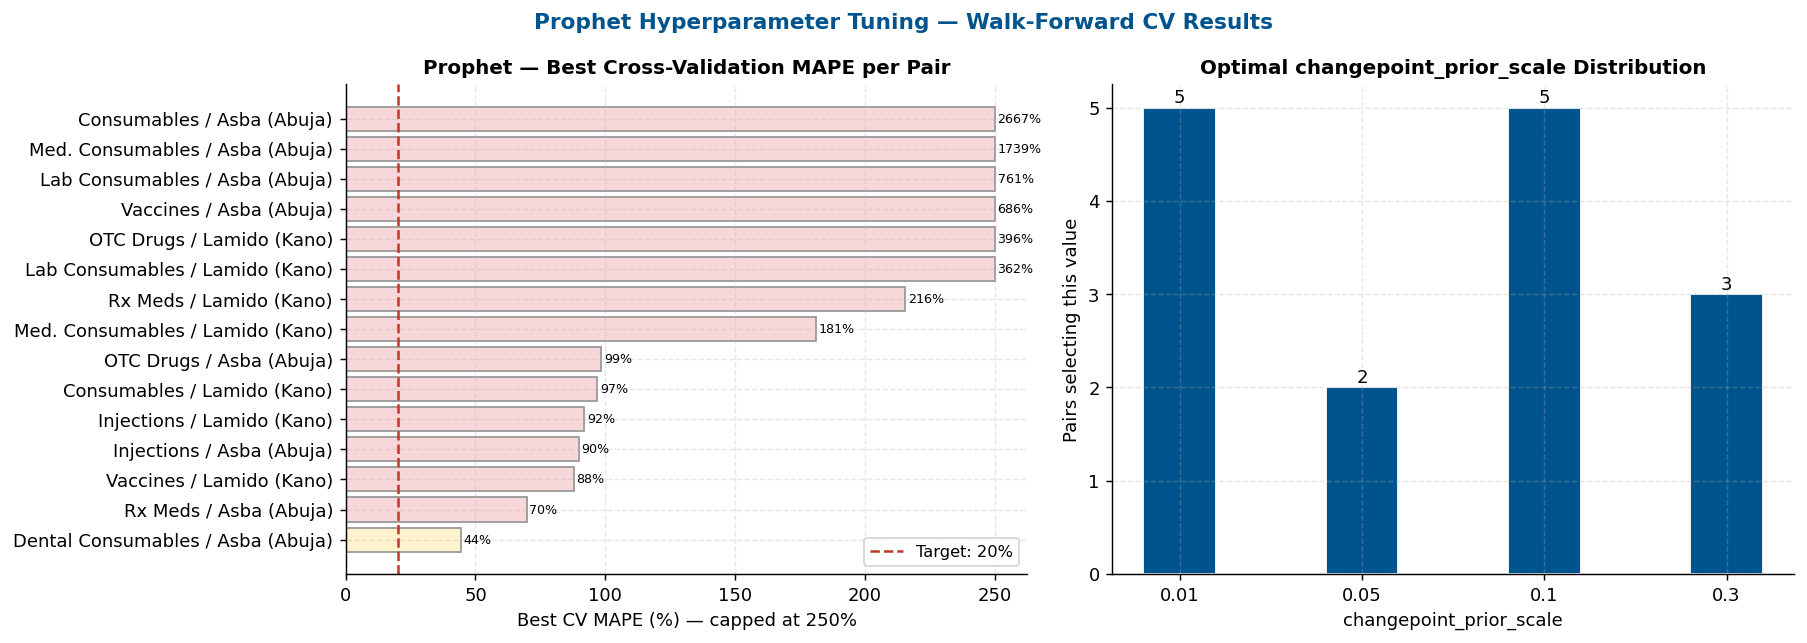

In [11]:
# ── Tuning results visualisation ──────────────────────────────────────────────
def colour_mape(val):
    if pd.isna(val):  return ''
    if val <= 20:     return 'background-color: #d4edda; color: #155724'
    if val <= 40:     return 'background-color: #fff3cd; color: #856404'
    return                   'background-color: #f8d7da; color: #721c24'


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Best CV MAPE per pair
t_sorted  = tuning_df.sort_values('best_cv_mape')
labels    = t_sorted['cat_short'] + ' / ' + t_sorted['branch_short']
bar_clrs  = [
    '#d4edda' if not np.isnan(m) and m <= 20
    else '#fff3cd' if not np.isnan(m) and m <= 50
    else '#f8d7da'
    for m in t_sorted['best_cv_mape']
]
bars = axes[0].barh(labels, t_sorted['best_cv_mape'].clip(upper=250),
                    color=bar_clrs, edgecolor='#999')
axes[0].axvline(20, color=RED, linestyle='--', linewidth=1.4, label='Target: 20%')
axes[0].set_xlabel('Best CV MAPE (%) — capped at 250%')
axes[0].set_title('Prophet — Best Cross-Validation MAPE per Pair')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, t_sorted['best_cv_mape']):
    if not np.isnan(val):
        axes[0].text(
            min(bar.get_width(), 250) + 1,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}%', va='center', fontsize=7
        )

# Right: Selected changepoint_prior_scale distribution
cp_vals   = [r['best_params']['changepoint_prior_scale'] for r in tuning_results]
cp_counts = pd.Series(cp_vals).value_counts().sort_index()
axes[1].bar(cp_counts.index.astype(str), cp_counts.values,
            color=BLUE, edgecolor='white', width=0.4)
for i, v in enumerate(cp_counts.values):
    axes[1].text(i, v + 0.05, str(v), ha='center', fontsize=10)
axes[1].set_xlabel('changepoint_prior_scale')
axes[1].set_ylabel('Pairs selecting this value')
axes[1].set_title('Optimal changepoint_prior_scale Distribution')

fig.suptitle('Prophet Hyperparameter Tuning — Walk-Forward CV Results',
             fontsize=12, fontweight='bold', color=BLUE)
plt.tight_layout()
plt.show()

## 5. Tier 3 — Final Hold-Out Validation

Each pair is fitted using its best hyperparameter set (from CV tuning), trained on the **full training window** (Jan 2021 – Dec 2023) and evaluated on the **hold-out validation set** (Jan – Jun 2024).

**Special cases:**
- **Lab Consumables / Asba:** Validation window is all-zero (known data gap). MAPE = NaN — forecast is still produced for planning purposes. Root cause investigation recommended before Tier 4.
- **Lab Consumables / Kano Lamido:** Extreme training volatility (ETS MAPE: 7,493%). Prophet's changepoint detection should yield more robust trend estimation.

In [12]:
print('Running Tier 3 final validation...')
tier3_rows = []

for seq, t_row in enumerate(tuning_results, start=1):
    cat, branch  = t_row['category'], t_row['branch']
    params       = t_row['best_params']
    pair_label   = f'{t_row["cat_short"]:20s} @ {t_row["branch_short"]}'

    train = get_pair_series(cat, branch, df_train)
    val   = get_pair_series(cat, branch, df_val)

    fc_series = None
    val_mape  = np.nan
    try:
        fc       = prophet_forecast(train, len(val), NG_HOLIDAYS, params)
        fc_series = pd.Series(np.maximum(fc, 0), index=val.index)
        val_mape  = mape(val.values, fc_series.values)
    except Exception as e:
        print(f'  [{seq:02d}] ERROR on {pair_label}: {e}')

    tier3_rows.append({
        'category':    cat,
        'branch':      branch,
        'cat_short':   t_row['cat_short'],
        'branch_short':t_row['branch_short'],
        'readiness':   t_row['readiness'],
        'high_risk':   t_row['high_risk'],
        'cv_mape':     round(t_row['best_cv_mape'], 1) if not np.isnan(t_row['best_cv_mape']) else np.nan,
        'val_mape':    round(val_mape, 1) if not np.isnan(val_mape) else np.nan,
        'best_params': params,
        'fc_series':   fc_series,
    })

    mape_str = f'{val_mape:6.1f}%' if not np.isnan(val_mape) else '   N/A '
    cv_str   = f'{t_row["best_cv_mape"]:6.1f}%' if not np.isnan(t_row['best_cv_mape']) else '   N/A '
    print(f'  [{seq:02d}/{len(tuning_results)}] {pair_label:43s}  val={mape_str}  cv={cv_str}')

tier3_df   = pd.DataFrame(tier3_rows)
evaluable  = tier3_df['val_mape'].notna().sum()
meets_t3   = (tier3_df['val_mape'] <= 20).sum()
print(f'\nDone.')
print(f'Evaluable pairs   : {evaluable} / {len(tier3_df)}')
print(f'MAPE ≤ 20%        : {meets_t3} / {evaluable}')
best_idx = tier3_df['val_mape'].idxmin()
print(f'Best Prophet MAPE : {tier3_df.loc[best_idx, "val_mape"]:.1f}%  '
      f'({tier3_df.loc[best_idx, "cat_short"]} / {tier3_df.loc[best_idx, "branch_short"]})')

15:35:39 - cmdstanpy - INFO - Chain [1] start processing


Running Tier 3 final validation...


15:35:39 - cmdstanpy - INFO - Chain [1] done processing
15:35:40 - cmdstanpy - INFO - Chain [1] start processing


  [01/15] Consumables          @ Asba (Abuja)          val= 100.0%  cv=2667.0%


15:35:40 - cmdstanpy - INFO - Chain [1] done processing
15:35:40 - cmdstanpy - INFO - Chain [1] start processing


...

  [13/15] Rx Meds              @ Lamido (Kano)         val=5172.9%  cv= 215.5%


15:35:47 - cmdstanpy - INFO - Chain [1] done processing
15:35:47 - cmdstanpy - INFO - Chain [1] start processing


  [14/15] Vaccines             @ Asba (Abuja)          val=  90.6%  cv= 685.9%


15:35:47 - cmdstanpy - INFO - Chain [1] done processing


  [15/15] Vaccines             @ Lamido (Kano)         val=  90.7%  cv=  87.9%

Done.
Evaluable pairs   : 14 / 15
MAPE ≤ 20%        : 0 / 14
Best Prophet MAPE : 90.6%  (Vaccines / Asba (Abuja))


In [13]:
# ── Tier 3 Results Table ───────────────────────────────────────────────────────
t3_display = tier3_df[['cat_short', 'branch_short', 'readiness', 'cv_mape', 'val_mape']].rename(columns={
    'cat_short':    'Category',
    'branch_short': 'Facility',
    'readiness':    'Tier',
    'cv_mape':      'CV MAPE (tuning)',
    'val_mape':     'Prophet MAPE (val)',
}).sort_values('Prophet MAPE (val)')

styled_t3 = (
    t3_display.style
    .map(colour_mape, subset=['CV MAPE (tuning)', 'Prophet MAPE (val)'])
    .set_caption('Tier 3 — Prophet Validation MAPE (Jan–Jun 2024)')
    .format({'CV MAPE (tuning)': '{:.1f}%', 'Prophet MAPE (val)': '{:.1f}%'}, na_rep='—')
)
display(styled_t3)

,Category,Facility,Tier,CV MAPE (tuning),Prophet MAPE (val)
13,Vaccines,Asba (Abuja),A,685.9%,90.6%
14,Vaccines,Lamido (Kano),B,87.9%,90.7%
2,Dental Consumables,Asba (Abuja),B,44.3%,98.0%
3,Injections,Asba (Abuja),A,89.8%,98.9%
0,Consumables,Asba (Abuja),A,2667.0%,100.0%
9,OTC Drugs,Asba (Abuja),A,98.5%,100.0%
7,Med. Consumables,Asba (Abuja),A,1738.6%,100.0%
11,Rx Meds,Asba (Abuja),A,69.6%,129.5%
1,Consumables,Lamido (Kano),A,96.9%,819.1%
8,Med. Consumables,Lamido (Kano),A,181.2%,878.5%


## 6. Full Model Comparison: Tier 1 → Tier 3

Side-by-side comparison of Prophet against all Tier 1 & 2 models.  
- **Green** = MAPE ≤ 20% (target met)  
- **Improvement (pp)** = Tier 1+2 best MAPE minus Prophet MAPE (positive = Prophet improves)  
- Note: MAPE values above 200% are capped in charts for readability

In [14]:
# ── Merge Tier 1+2 baseline with Tier 3 results ───────────────────────────────
comp = baseline_df[
    ['category', 'branch', 'cat_short', 'branch_short', 'readiness', 'high_risk',
     'Seas. Naïve', 'Roll. Avg', 'ETS', 'SARIMA', 'Theta',
     'best_t12_mape', 'best_t12_model']
].merge(
    tier3_df[['category', 'branch', 'val_mape', 'fc_series']].rename(columns={'val_mape': 'Prophet'}),
    on=['category', 'branch'],
    how='left',
)

comp['improvement']  = comp['best_t12_mape'] - comp['Prophet']
comp['best_overall'] = comp[['best_t12_mape', 'Prophet']].min(axis=1)
comp['best_model']   = comp.apply(
    lambda r: 'Prophet'
    if (pd.notna(r['Prophet']) and (pd.isna(r['best_t12_mape']) or r['Prophet'] <= r['best_t12_mape']))
    else r['best_t12_model'],
    axis=1,
)
comp['meets_target'] = comp['best_overall'] <= 20

n_met      = comp['meets_target'].sum()
n_improved = (comp['improvement'] > 0).sum()
n_prophet_eval = comp['Prophet'].notna().sum()

print(f'Pairs meeting MAPE ≤ 20% (any model, Tier 1–3) : {n_met} / {len(comp)}')
print(f'Pairs where Prophet improves on Tier 1+2        : {n_improved} / {n_prophet_eval}')
print(f'Pairs still above target (→ Tier 4 or accept)   : {len(comp) - n_met} / {len(comp)}')
print()
print(f'  {"Category":<22} {"Facility":<22} {"T1+2 Best":>10}  {"Prophet":>9}  {"Δ (pp)":>8}  Status')
print('  ' + '─' * 82)
for _, r in comp.sort_values('improvement', ascending=False).iterrows():
    t12  = f'{r["best_t12_mape"]:6.1f}%' if pd.notna(r['best_t12_mape']) else '   N/A '
    t3   = f'{r["Prophet"]:6.1f}%'        if pd.notna(r['Prophet'])        else '   N/A '
    diff = f'{r["improvement"]:+6.1f}pp'  if pd.notna(r['improvement'])    else '     N/A'
    flag = '✓' if r['meets_target'] else '⚠'
    print(f'  {r["cat_short"]:<22} {r["branch_short"]:<22} {t12:>10}  {t3:>9}  {diff:>8}  {flag}')

Pairs meeting MAPE ≤ 20% (any model, Tier 1–3) : 0 / 15
Pairs where Prophet improves on Tier 1+2        : 0 / 14
Pairs still above target (→ Tier 4 or accept)   : 15 / 15

  Category               Facility                T1+2 Best    Prophet    Δ (pp)  Status
  ──────────────────────────────────────────────────────────────────────────────────
  Dental Consumables     Asba (Abuja)                91.3%      98.0%    -6.7pp  ⚠
  Vaccines               Asba (Abuja)                82.9%      90.6%    -7.7pp  ⚠
  Injections             Asba (Abuja)                85.0%      98.9%   -13.9pp  ⚠
  Consumables            Asba (Abuja)                84.9%     100.0%   -15.1pp  ⚠
  Med. Consumables       Asba (Abuja)                73.2%     100.0%   -26.8pp  ⚠
  OTC Drugs              Asba (Abuja)                73.0%     100.0%   -27.0pp  ⚠
  Vaccines               Lamido (Kano)               44.8%      90.7%   -45.9pp  ⚠
  Rx Meds                Asba (Abuja)                80.7%     129.5%   -4

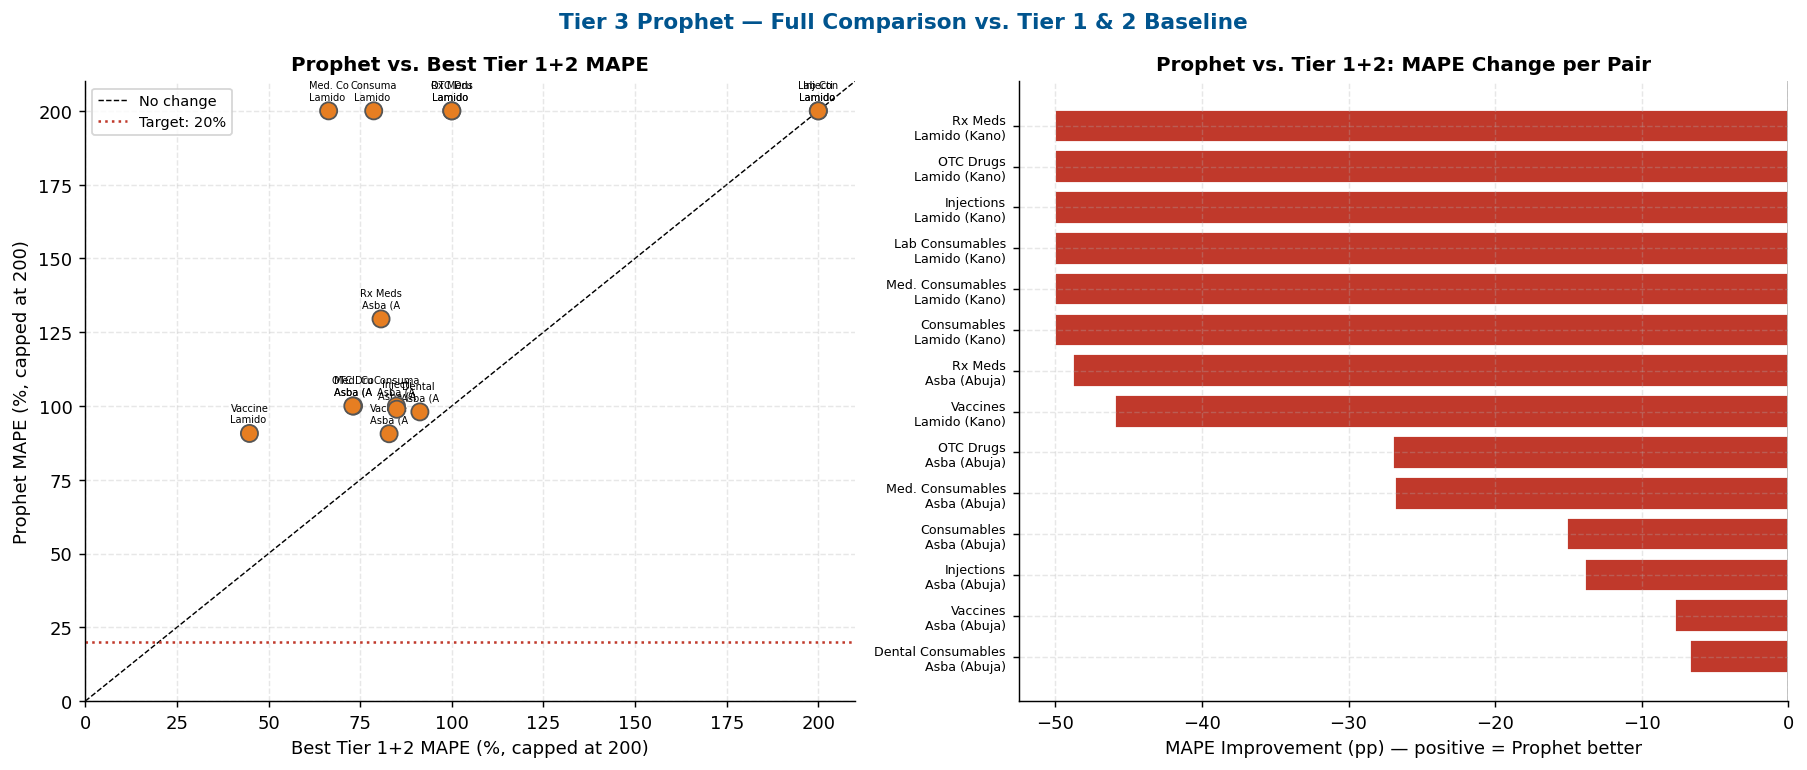

In [15]:
# ── Comparison visualisation ───────────────────────────────────────────────────
MAPE_CAP = 200  # cap extreme values for chart readability

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Tier 1+2 best vs Prophet scatter
ev = comp.dropna(subset=['Prophet', 'best_t12_mape']).copy()
ev['x_capped'] = ev['best_t12_mape'].clip(upper=MAPE_CAP)
ev['y_capped'] = ev['Prophet'].clip(upper=MAPE_CAP)

axes[0].scatter(
    ev['x_capped'], ev['y_capped'],
    c=[GREEN if v else AMBER for v in (ev['Prophet'] <= 20)],
    s=90, edgecolors='#555', zorder=5
)
lim = MAPE_CAP * 1.05
axes[0].plot([0, lim], [0, lim], 'k--', linewidth=0.8, label='No change', zorder=1)
axes[0].axhline(20, color=RED, linestyle=':', linewidth=1.4, label='Target: 20%', zorder=2)
axes[0].set_xlim(0, lim)
axes[0].set_ylim(0, lim)
axes[0].set_xlabel(f'Best Tier 1+2 MAPE (%, capped at {MAPE_CAP})')
axes[0].set_ylabel(f'Prophet MAPE (%, capped at {MAPE_CAP})')
axes[0].set_title('Prophet vs. Best Tier 1+2 MAPE')
axes[0].legend(fontsize=8)

# Annotate points below the diagonal (Prophet better)
for _, r in ev.iterrows():
    axes[0].annotate(
        f'{r["cat_short"][:7]}\n{r["branch_short"][:7]}',
        (r['x_capped'], r['y_capped']),
        fontsize=5.5, ha='center', va='bottom',
        xytext=(0, 5), textcoords='offset points'
    )

# Right: MAPE improvement bar chart
comp_imp = comp.dropna(subset=['improvement']).sort_values('improvement', ascending=False)
pair_labels = comp_imp['cat_short'] + '\n' + comp_imp['branch_short']
bar_clrs    = [GREEN if v > 0 else RED for v in comp_imp['improvement']]
axes[1].barh(pair_labels, comp_imp['improvement'].clip(lower=-50, upper=50),
             color=bar_clrs, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('MAPE Improvement (pp) — positive = Prophet better')
axes[1].set_title('Prophet vs. Tier 1+2: MAPE Change per Pair')
axes[1].tick_params(axis='y', labelsize=7)

fig.suptitle('Tier 3 Prophet — Full Comparison vs. Tier 1 & 2 Baseline',
             fontsize=12, fontweight='bold', color=BLUE)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'tier3_comparison.pdf', bbox_inches='tight')
plt.show()

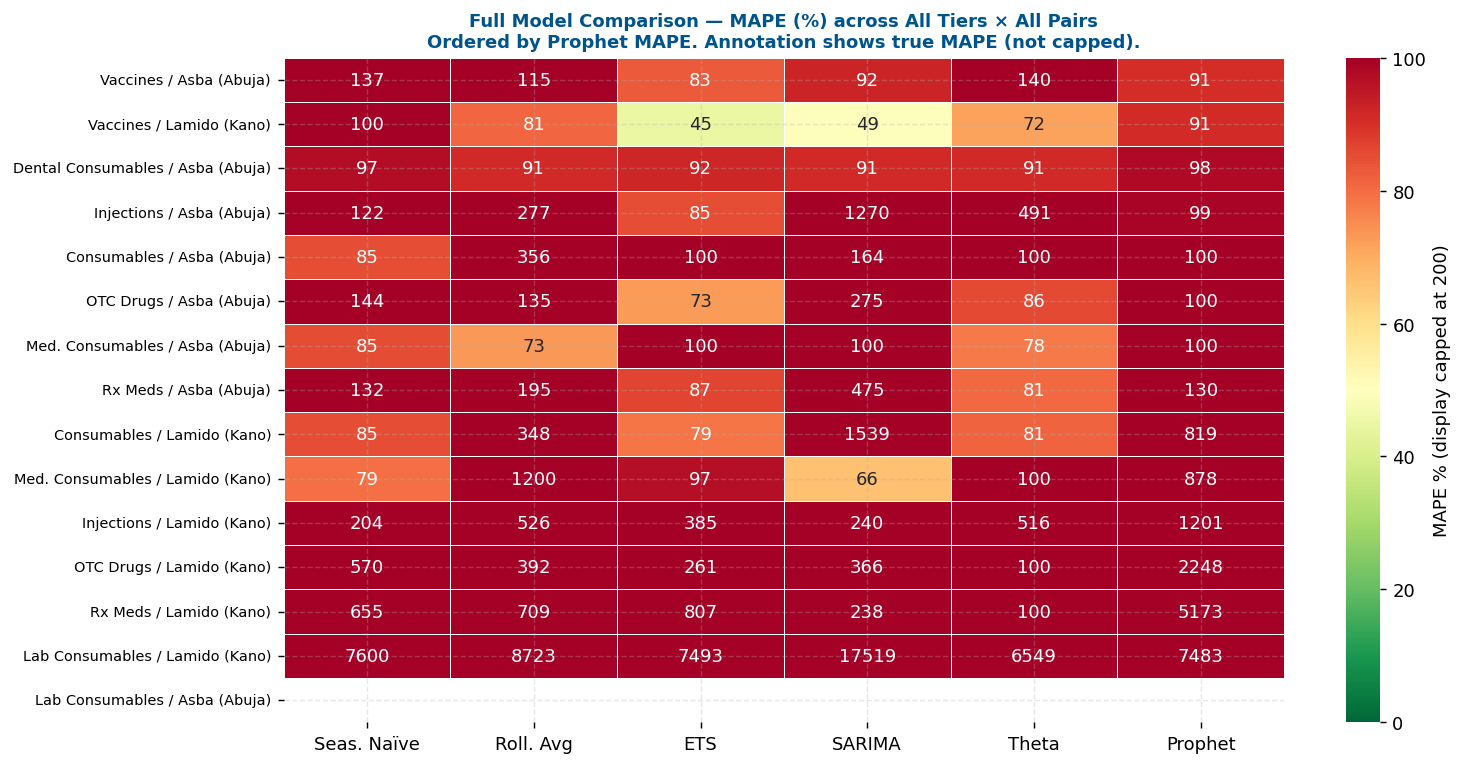

In [16]:
# ── Full 6-model MAPE heatmap (Tier 1 + 2 + Prophet) ─────────────────────────
hmap_data = comp.set_index(
    comp['cat_short'] + ' / ' + comp['branch_short']
)[['Seas. Naïve', 'Roll. Avg', 'ETS', 'SARIMA', 'Theta', 'Prophet']].copy()

# Sort by Prophet MAPE for readability
hmap_data = hmap_data.reindex(hmap_data['Prophet'].sort_values().index)

# Cap extreme values so the colour scale is informative
hmap_display = hmap_data.clip(upper=200)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    hmap_display, ax=ax,
    cmap='RdYlGn_r', annot=hmap_data.round(0), fmt='.0f',
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'MAPE % (display capped at 200)'},
    vmin=0, vmax=100
)
ax.set_title(
    'Full Model Comparison — MAPE (%) across All Tiers × All Pairs\n'
    'Ordered by Prophet MAPE. Annotation shows true MAPE (not capped).',
    color=BLUE, fontsize=10
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'tier3_full_heatmap.pdf', bbox_inches='tight')
plt.show()

## 7. Forecast Plots — Tier 3 Prophet

Forecast vs. actual for the top pairs sorted by Prophet MAPE. Green title = target met (MAPE ≤ 20%). These are the production forecast candidates for the procurement planning cycle.

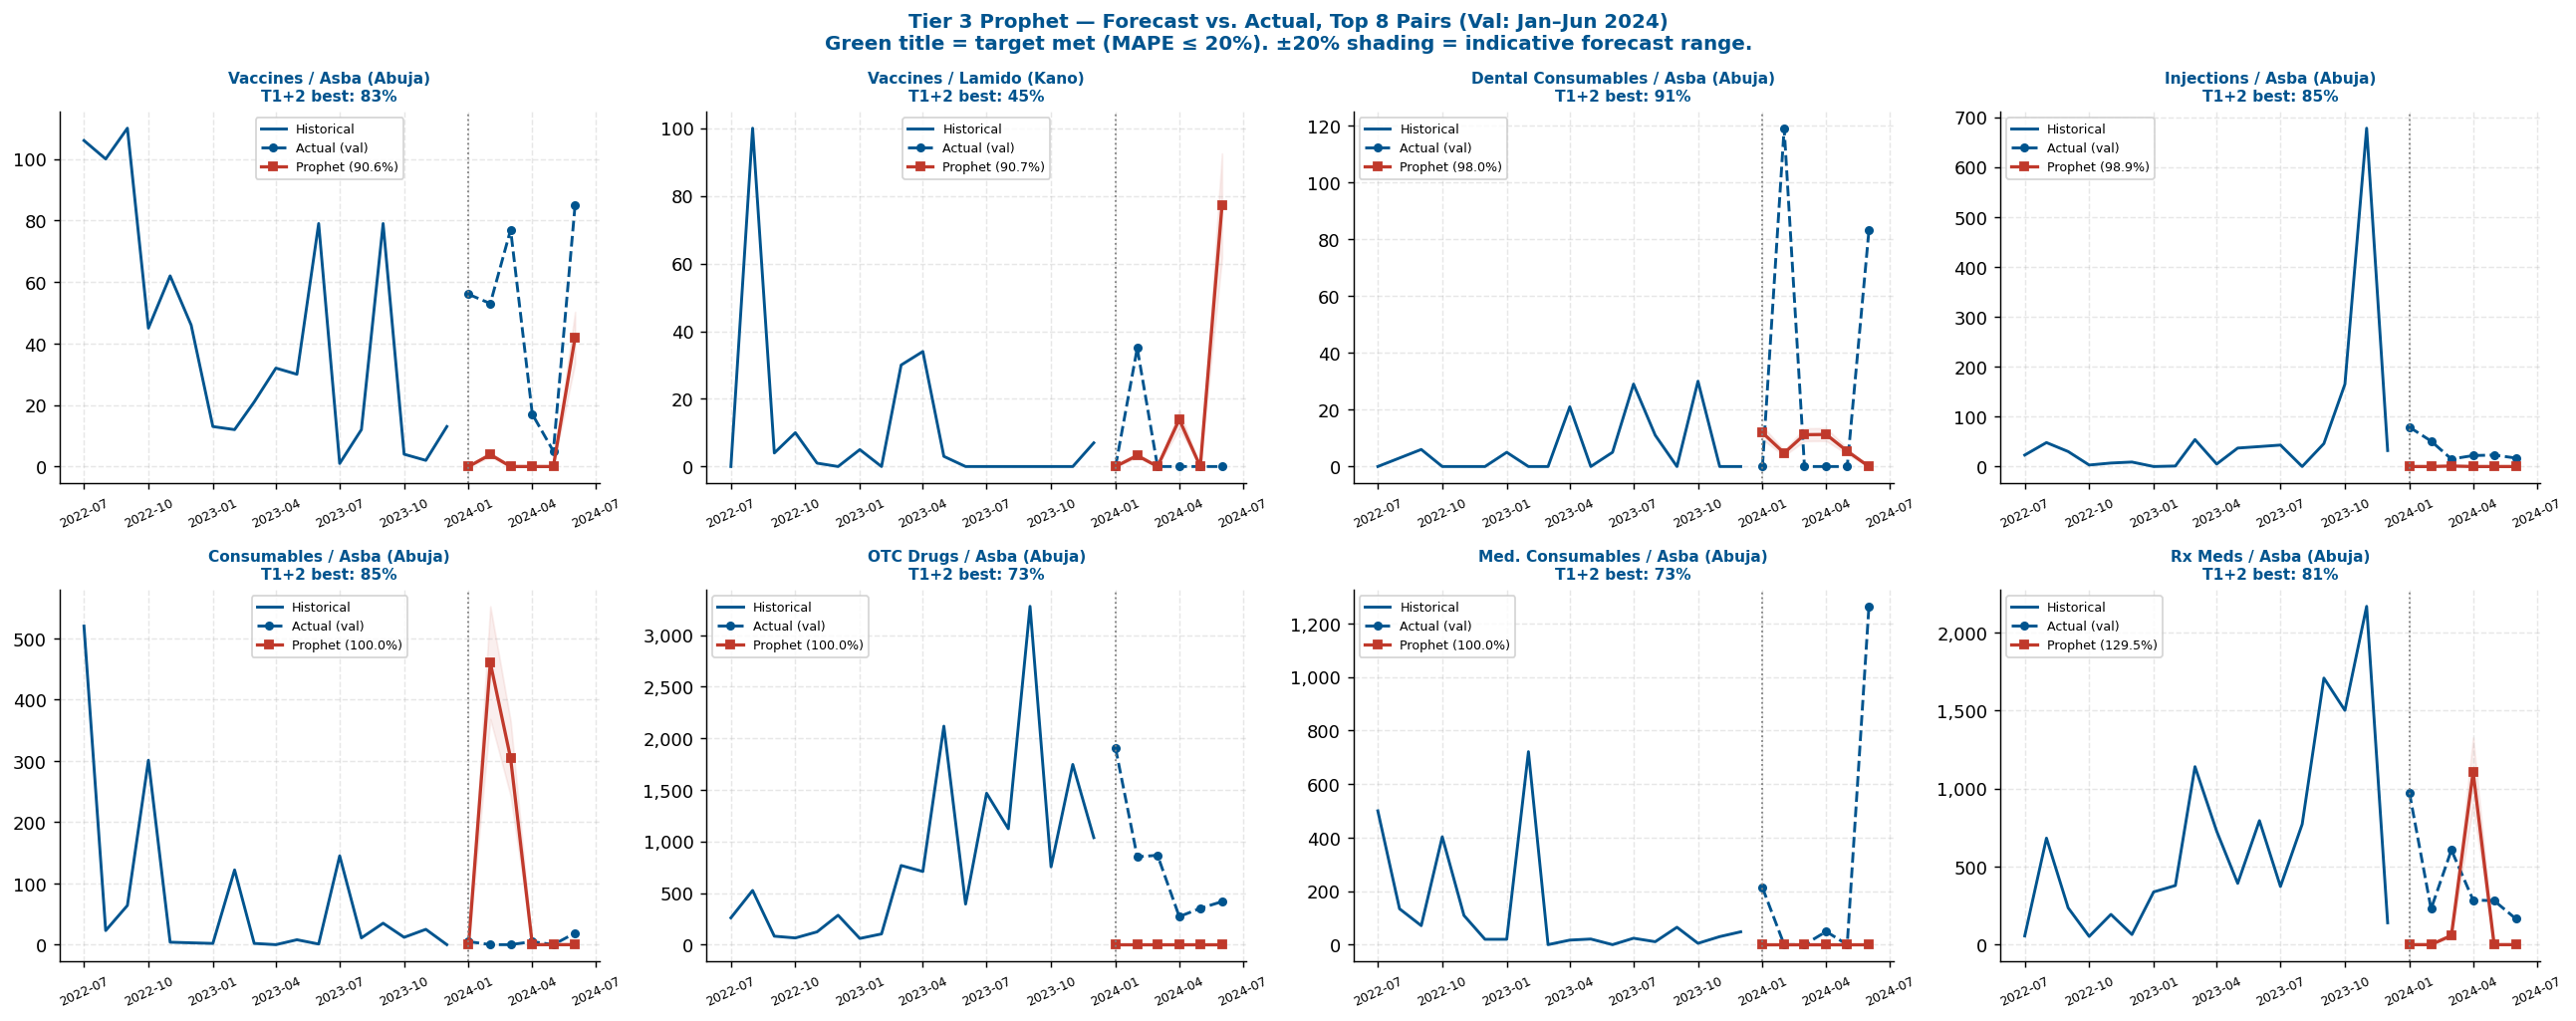

In [17]:
# ── Forecast plots — top 8 pairs by Prophet validation MAPE ──────────────────
plot_pairs = (
    comp
    .dropna(subset=['Prophet'])
    .sort_values('Prophet')
    .head(8)
)

n     = len(plot_pairs)
ncols = min(4, n)
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=False)
axes_flat = np.array(axes).flatten() if n > 1 else [axes]

for ax, (_, row) in zip(axes_flat, plot_pairs.iterrows()):
    cat, branch = row['category'], row['branch']
    train_s = get_pair_series(cat, branch, df_train)
    val_s   = get_pair_series(cat, branch, df_val)
    fc_s    = row['fc_series']

    ax.plot(train_s.index[-18:], train_s.values[-18:],
            color=BLUE, linewidth=1.6, label='Historical')
    ax.plot(val_s.index, val_s.values,
            color=BLUE, linewidth=1.6, linestyle='--',
            marker='o', markersize=4, label='Actual (val)')

    if fc_s is not None:
        ax.plot(fc_s.index, fc_s.values,
                color=RED, linewidth=1.8,
                marker='s', markersize=4,
                label=f'Prophet ({row["Prophet"]:.1f}%)')
        ax.fill_between(fc_s.index,
                        fc_s.values * 0.8, fc_s.values * 1.2,
                        color=RED, alpha=0.08)

    ax.axvline(val_s.index[0], color='grey', linestyle=':', linewidth=1)
    target_met  = pd.notna(row['Prophet']) and row['Prophet'] <= 20
    title_colour = GREEN if target_met else BLUE
    t12_note    = f'T1+2 best: {row["best_t12_mape"]:.0f}%' if pd.notna(row['best_t12_mape']) else ''
    ax.set_title(
        f'{row["cat_short"]} / {row["branch_short"]}\n{t12_note}',
        fontsize=8.5, color=title_colour
    )
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.legend(fontsize=7)
    ax.tick_params(axis='x', rotation=25, labelsize=7)

for ax in axes_flat[n:]:
    ax.set_visible(False)

fig.suptitle(
    'Tier 3 Prophet — Forecast vs. Actual, Top 8 Pairs (Val: Jan–Jun 2024)\n'
    'Green title = target met (MAPE ≤ 20%). ±20% shading = indicative forecast range.',
    fontsize=11, fontweight='bold', color=BLUE
)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'tier3_forecast_plots.pdf', bbox_inches='tight')
plt.show()

## 8. Q3 Baseline Report

The official Q3 assessment: pairs that have met the ≤ 20% MAPE target, recommended production model, and pairs requiring escalation to **Tier 4 (XGBoost / Random Forest)**.

In [18]:
# ── Q3 Baseline Report (text) ─────────────────────────────────────────────────
t12_met  = (comp['best_t12_mape'] <= 20).sum()
t3_only  = ((comp['Prophet'] <= 20) & ((comp['best_t12_mape'] > 20) | comp['best_t12_mape'].isna())).sum()
need_t4  = (~comp['meets_target']).sum()
n_total  = len(comp)

print('=' * 74)
print('  Q3 BASELINE MAPE REPORT — EHA Clinics Procurement Forecasting')
print('  Tier 3 (Prophet)  |  Validation window: Jan 2024 – Jun 2024')
print('=' * 74)
print()
print(f'  Eligible pairs (Tier A + B)              : {n_total}')
print(f'  Pairs meeting MAPE ≤ 20% at Tier 1+2    : {t12_met} / {n_total}')
print(f'  Pairs first meeting target at Tier 3     : {t3_only} / {n_total}')
print(f'  Total pairs meeting target (Tier 1–3)    : {n_met} / {n_total}')
print(f'  Pairs requiring Tier 4 (ML)              : {need_t4} / {n_total}')
print(f'  Tier C (insufficient data, no model)     : {len(tier_c)}')
print()
print(f'  {"Category":<22} {"Facility":<22} {"Best T1+2":>10} {"Prophet":>9} {"Best":>7}  Model              Status')
print('  ' + '─' * 100)
for _, r in comp.sort_values('best_overall').iterrows():
    t12_s  = f'{r["best_t12_mape"]:6.1f}%' if pd.notna(r['best_t12_mape']) else '    N/A '
    t3_s   = f'{r["Prophet"]:6.1f}%'        if pd.notna(r['Prophet'])        else '    N/A '
    best_s = f'{r["best_overall"]:6.1f}%'   if pd.notna(r['best_overall'])   else '    N/A '
    status = '✓ TARGET MET'  if r['meets_target']  else '⚠  ESCALATE → Tier 4'
    print(f'  {r["cat_short"]:<22} {r["branch_short"]:<22} {t12_s:>10} {t3_s:>9} {best_s:>7}  '
          f'{r["best_model"]:<18}  {status}')
print()
print('  HIGH-RISK FINANCIAL PAIRS (Laboratory Consumables):')
for _, r in comp[comp['high_risk']].iterrows():
    best_s = f'{r["best_overall"]:6.1f}%' if pd.notna(r['best_overall']) else '  N/A '
    flag   = '✓ TARGET MET' if r['meets_target'] else '⚠ ABOVE TARGET'
    print(f'    {r["cat_short"]:<22} @ {r["branch_short"]:<22}  Best MAPE={best_s}  {flag}')
print()
print('=' * 74)

  Q3 BASELINE MAPE REPORT — EHA Clinics Procurement Forecasting
  Tier 3 (Prophet)  |  Validation window: Jan 2024 – Jun 2024

  Eligible pairs (Tier A + B)              : 15
  Pairs meeting MAPE ≤ 20% at Tier 1+2    : 0 / 15
  Pairs first meeting target at Tier 3     : 0 / 15
  Total pairs meeting target (Tier 1–3)    : 0 / 15
  Pairs requiring Tier 4 (ML)              : 15 / 15
  Tier C (insufficient data, no model)     : 28

  Category               Facility                Best T1+2   Prophet    Best  Model              Status
  ────────────────────────────────────────────────────────────────────────────────────────────────────
  Vaccines               Lamido (Kano)               44.8%     90.7%   44.8%  ETS                 ⚠  ESCALATE → Tier 4
  Med. Consumables       Lamido (Kano)               66.4%    878.5%   66.4%  SARIMA              ⚠  ESCALATE → Tier 4
  OTC Drugs              Asba (Abuja)                73.0%    100.0%   73.0%  ETS                 ⚠  ESCALATE → Tier 4
  Me

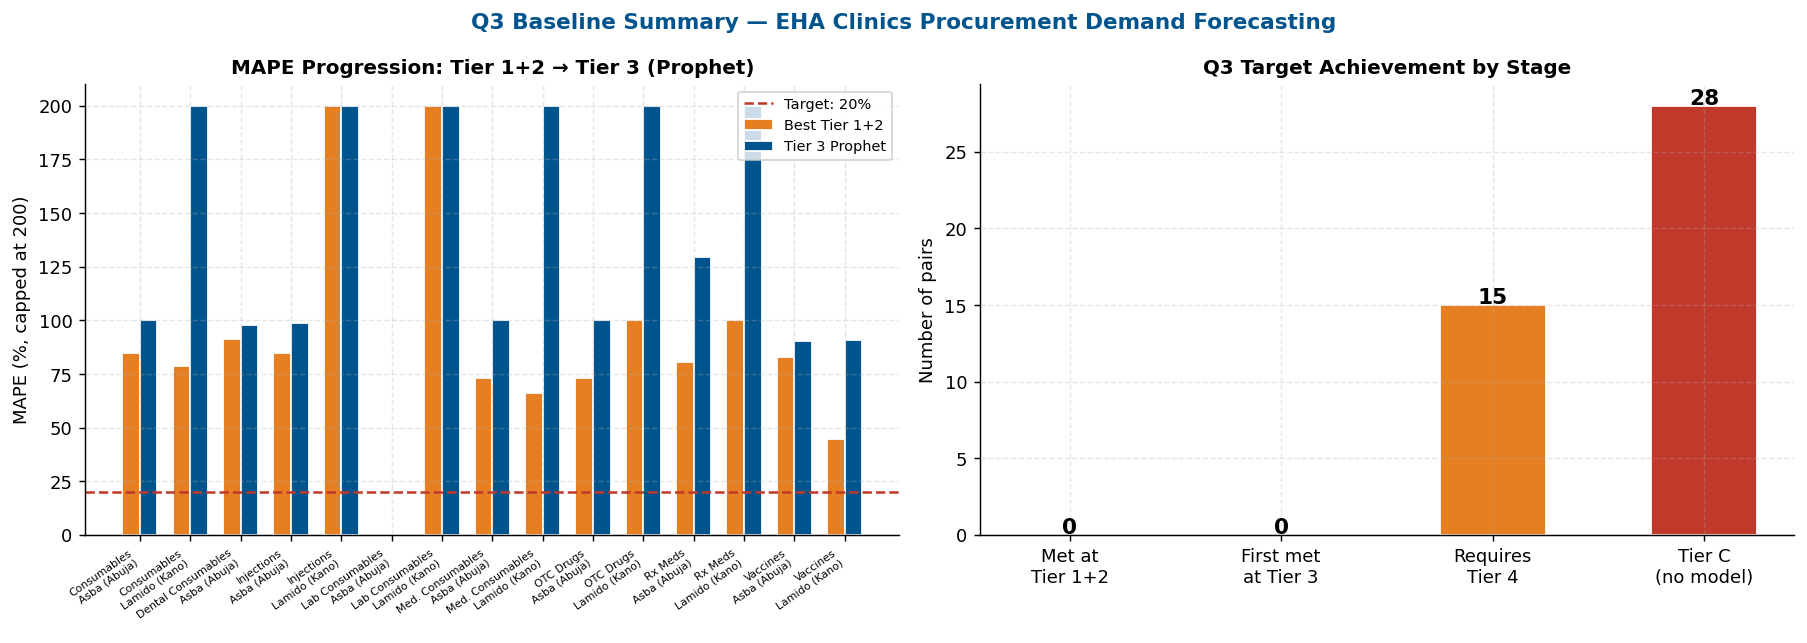


Outputs saved to: C:\Users\joshua.ogundairo\Desktop\Clinics\Procurement Predictive Modeling\reports
  tier3_comparison.pdf    — Prophet vs. Tier 1+2 scatter & improvement chart
  tier3_full_heatmap.pdf  — 6-model MAPE heatmap across all pairs
  tier3_forecast_plots.pdf — Forecast vs. actual, top 8 pairs
  tier3_q3_summary.pdf    — Q3 target achievement summary


In [19]:
# ── Q3 Summary Visualisation ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: MAPE progression Tier 1+2 → Prophet (capped)
comp_s = comp.sort_values('cat_short')
x      = np.arange(len(comp_s))
w      = 0.35
t12_v  = comp_s['best_t12_mape'].fillna(0).clip(upper=MAPE_CAP).values
t3_v   = comp_s['Prophet'].fillna(0).clip(upper=MAPE_CAP).values
pair_l = [f'{c}\n{b}' for c, b in zip(comp_s['cat_short'], comp_s['branch_short'])]

axes[0].bar(x - w / 2, t12_v, w, color=AMBER, label='Best Tier 1+2', edgecolor='white')
axes[0].bar(
    x + w / 2, t3_v, w,
    color=[GREEN if (not np.isnan(v) and v <= 20) else BLUE
           for v in comp_s['Prophet'].fillna(np.nan)],
    label='Tier 3 Prophet', edgecolor='white'
)
axes[0].axhline(20, color=RED, linestyle='--', linewidth=1.4, label='Target: 20%')
axes[0].set_xticks(x)
axes[0].set_xticklabels(pair_l, fontsize=6, rotation=35, ha='right')
axes[0].set_ylabel(f'MAPE (%, capped at {MAPE_CAP})')
axes[0].set_title('MAPE Progression: Tier 1+2 → Tier 3 (Prophet)')
axes[0].legend(fontsize=8)

# Right: Target achievement breakdown by stage
stage_labels = [
    'Met at\nTier 1+2',
    'First met\nat Tier 3',
    'Requires\nTier 4',
    'Tier C\n(no model)',
]
stage_counts = [t12_met, t3_only, need_t4, len(tier_c)]
bar_colours  = [GREEN, BLUE, AMBER, RED]

axes[1].bar(stage_labels, stage_counts, color=bar_colours, edgecolor='white', width=0.5)
for i, v in enumerate(stage_counts):
    axes[1].text(i, v + 0.1, str(v), ha='center', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of pairs')
axes[1].set_title('Q3 Target Achievement by Stage')

fig.suptitle('Q3 Baseline Summary — EHA Clinics Procurement Demand Forecasting',
             fontsize=12, fontweight='bold', color=BLUE)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'tier3_q3_summary.pdf', bbox_inches='tight')
plt.show()

print(f'\nOutputs saved to: {REPORTS_DIR}')
print('  tier3_comparison.pdf    — Prophet vs. Tier 1+2 scatter & improvement chart')
print('  tier3_full_heatmap.pdf  — 6-model MAPE heatmap across all pairs')
print('  tier3_forecast_plots.pdf — Forecast vs. actual, top 8 pairs')
print('  tier3_q3_summary.pdf    — Q3 target achievement summary')